In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import svm
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge, SGDRegressor, ElasticNet

## Data preprocessing

In [31]:
# xl_file = pd.ExcelFile("Raton1 388X_.xlsx")
# dfs = {sheet_name: xl_file.parse(sheet_name) 
#          for sheet_name in xl_file.sheet_names}
# data = np.array(dfs['GnRH 10nM 40seg'])

In [32]:
# np.save('data.npy', data)
data = np.load('data.npy')

In [33]:
rs = np.random.RandomState(0)
# data_ = data.transpose() - data.transpose().mean(axis=0)
data_ = data[:,1:] # probablemente quita el identificador de los datos, dejando los demas campos.
data_.shape
# data_ /= data_.std(axis=0)

(999, 507)

Muestra la forma de los datos (como se comportan las células en estímulos de tiempo)

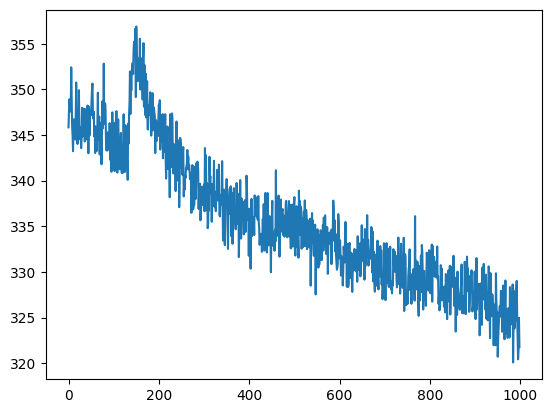

In [34]:
plt.plot(np.array(range(len(data_[:, 15]))).reshape(-1, 1), data_[:, 15])
ax = plt.gca()
plt.show()

## Data normalization

In [35]:
norm_data = np.zeros(data_.shape) # crea un arreglo con zeros en la forma de los datos

for i in range(data_.shape[1]): 
    reg = ElasticNet().fit(np.array(range(len(data_[:, i]))).reshape(-1, 1), data_[:, i])
    #reg = svm.SVR().fit(np.array(range(len(data_[:, i]))).reshape(-1, 1), data_[:, i])
    res = reg.predict(np.array(range(len(data_[:, i]))).reshape(-1, 1))
    norm_data[:, i] = data_[:, i] - res # resta la funcion
    min_data = min(norm_data[:, i])
    max_data = max(norm_data[:, i])
    #norm_data[:, i] = data_[:, i] 
    norm_data[:, i] = norm_data[:, i] - min_data # opcion para nomalizar los datos
    #norm_data[:, i] = norm_data[:, i] / min_data # opcion para nomalizar los datos
    #norm_data[:, i] = (norm_data[:, i] - min_data) / (max_data - min_data) # opcion para nomalizar los datos

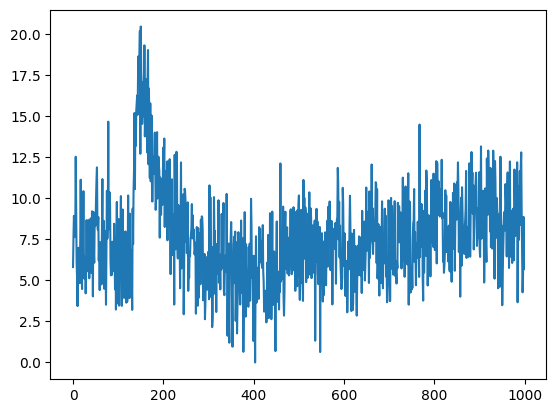

<Figure size 1000x600 with 0 Axes>

In [36]:
plt.plot(np.array(range(len(norm_data[:, 15]))).reshape(-1, 1), norm_data[:, 15])
ax = plt.gca()
plt.figure(figsize=(10,6))
plt.show()

In [37]:
norm_data.shape

(999, 507)

## Peak finding functions

A method to find peaks

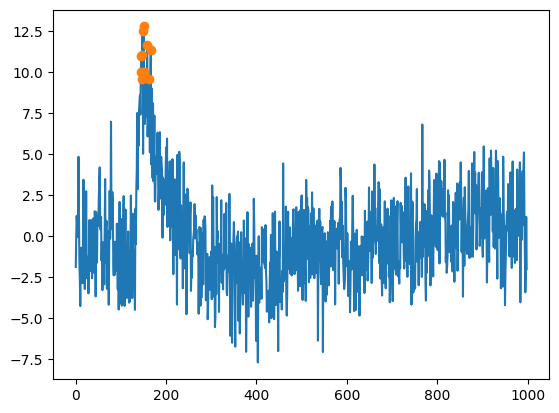

In [ ]:
#TODO: Arreglar el problema de que se pierden los datos en la normalizacion
from sklearn.covariance import EllipticEnvelope

pico_norm_data = norm_data[:,15]

reg = ElasticNet().fit(np.array(range(len(pico_norm_data))).reshape(-1, 1), pico_norm_data)
res = reg.predict(np.array(range(len(pico_norm_data))).reshape(-1, 1))

new_data = pico_norm_data - res
clf = EllipticEnvelope(random_state=0, contamination=0.01).fit(new_data.reshape(-1, 1))
y_pred = clf.predict(new_data.reshape(-1, 1))
#y_res = list(y_pred).index(-1)
y_res = [i for i, x in enumerate(list(y_pred)) if x == -1]

plt.plot(np.array(range(len(pico_norm_data))).reshape(-1, 1), pico_norm_data - res)
plt.plot(np.array(range(len(pico_norm_data))).reshape(-1, 1)[y_res], (pico_norm_data - res)[y_res], "o")
plt.show()

Implementation of the PeakCaller algorithm to find peaks:  
https://bmcneurosci.biomedcentral.com/articles/10.1186/s12868-017-0391-y#Sec2

In [39]:
def peak_caller(data, rise_percent, fall_percent, max_lookback, max_lookahead):
    peaks = []
    n = len(data)
    
    for i in range(n):
        # Ajusta el rango de lookback si se excede el rango de datos
        lookback_start = max(0, i - max_lookback)
        
        # Ajusta el rango de lookback para acortar si encuentra un pico
        lookback_range = []
        for j in range(i - 1, lookback_start - 1, -1):
            if j in peaks:
                break
            lookback_range.insert(0, data[j])
        
        # Ajusta el rango de lookahead si se excede el rango de datos
        lookahead_end = min(n, i + max_lookahead + 1)
        
        # Ajusta el range de lookahead para acortar si encuentra un punto mas grande que el actual
        lookahead_range = []
        for j in range(i + 1, lookahead_end):
            if data[j] > data[i]:
                break
            lookahead_range.append(data[j])
        
        # Si no esta vacio el rango de lookback y lookahead se calcula si es un pico
        if len(lookback_range) > 0 and len(lookahead_range) > 0:
            rise = data[i] * (rise_percent / 100.0)
            fall = data[i] * (fall_percent / 100.0)
            
            # Checa si los datos incrementan y decrementan lo suficiente para ser pico
            # Compara el valor actual con el minimo de los datos en el rango de lookback
            # Compara el valor actual con el maximo de los datos en el rango de lookahead
            significant_rise = data[i] - np.min(lookback_range) >= rise
            significant_fall = data[i] - np.min(lookahead_range) >= fall
            
            if significant_rise and significant_fall:
                peaks.append(i)
    
    return peaks

Examples without noise reduction

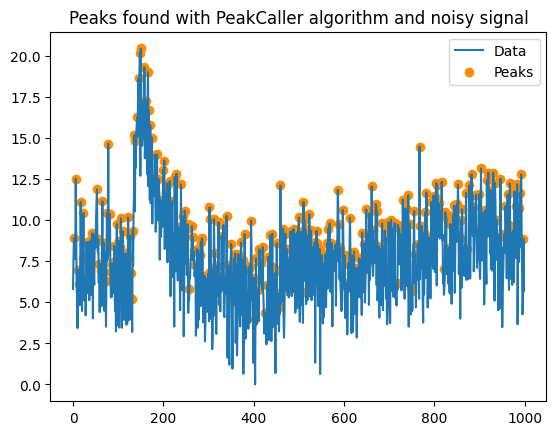

In [51]:
rise = 5
fall = 5
max_lookback = 10
max_lookahead = 10
detrended_data = norm_data[:, 15]

peaks = peak_caller(detrended_data, rise, fall, max_lookback, max_lookahead)

plt.plot(detrended_data, label='Data')
plt.scatter(peaks, detrended_data[peaks], color='darkorange', label='Peaks')
plt.title('Peaks found with PeakCaller algorithm and noisy signal')
plt.legend()
plt.show()

Examples with noise reduction function

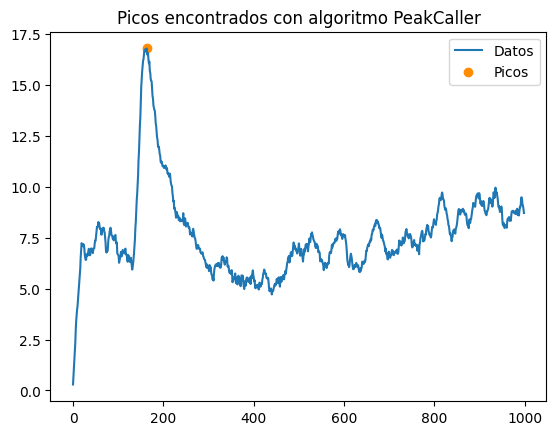

In [ ]:
from scipy.signal import lfilter
yy = norm_data[:, 15]

n = 20  # the larger n is, the smoother curve will be
b = [1.0 / n] * n
a = 1
yy = lfilter(b, a, yy)

rise = 30
fall = 30
max_lookback = 50
max_lookahead = 50

peaks = peak_caller(yy, rise, fall, max_lookback, max_lookahead)

plt.plot(yy, label='Datos')
plt.scatter(peaks, yy[peaks], color='darkorange', label='Picos')
plt.title('Picos encontrados con algoritmo PeakCaller')
plt.legend()
plt.show()

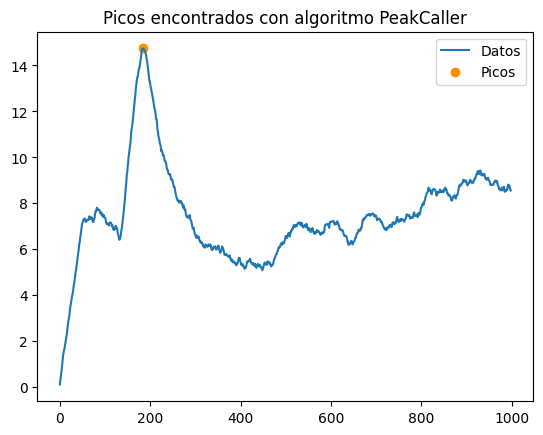

In [ ]:
from scipy.signal import lfilter
yy = norm_data[:, 15]

n = 50  # the larger n is, the smoother curve will be
b = [1.0 / n] * n
a = 1
yy = lfilter(b, a, yy)

rise = 30
fall = 30
max_lookback = 50
max_lookahead = 50

peaks = peak_caller(yy, rise, fall, max_lookback, max_lookahead)

plt.plot(yy, label='Datos')
plt.scatter(peaks, yy[peaks], color='darkorange', label='Picos')
plt.title('Picos encontrados con algoritmo PeakCaller')
plt.legend()
plt.show()

Another peak finding function

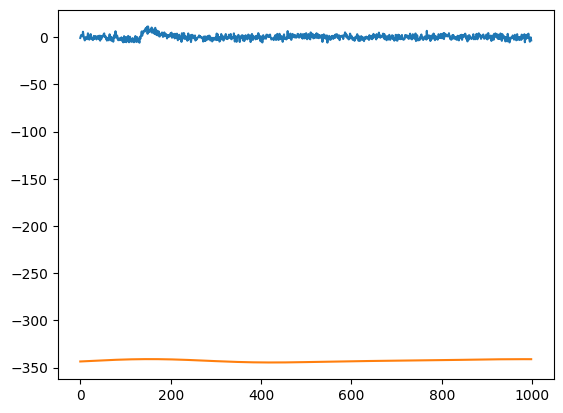

In [54]:
data_sel = norm_data[:, 15]
reg = svm.SVR().fit(np.array(range(len(data_sel))).reshape(-1, 1), data_sel)
res = reg.predict(np.array(range(len(data_sel))).reshape(-1, 1))

plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), data_sel - res)
plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), res - 350)
mean2 = (380 - 310) / 2
ax = plt.gca()

plt.show()

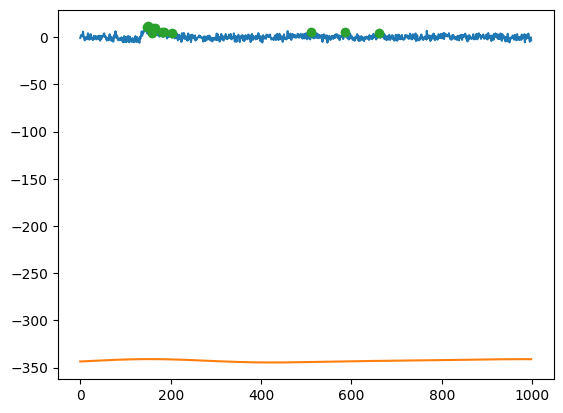

In [55]:
from sklearn.neighbors import LocalOutlierFactor
new_data = data_sel - res
clf = LocalOutlierFactor(n_neighbors=20)
y_pred = clf.fit_predict(new_data.reshape(-1, 1))
# y_res = list(y_pred).index(-1)
y_res = [i for i, x in enumerate(list(y_pred)) if x == -1]

plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), data_sel - res)
plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), res - 350)
plt.plot(np.array(range(len(data_sel))).reshape(-1, 1)[y_res], (data_sel - res)[y_res], "o")
mean2 = (380 - 310) / 2
ax = plt.gca()

plt.show()

Another peak finding function

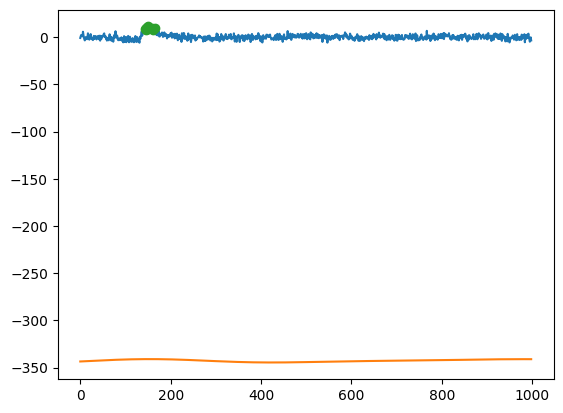

In [56]:
from sklearn.covariance import EllipticEnvelope
new_data = data_sel - res
clf = EllipticEnvelope(random_state=0, contamination=0.01).fit(new_data.reshape(-1, 1))
y_pred = clf.predict(new_data.reshape(-1, 1))
# y_res = list(y_pred).index(-1)
y_res = [i for i, x in enumerate(list(y_pred)) if x == -1]



plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), data_sel - res)
plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), res - 350)
plt.plot(np.array(range(len(data_sel))).reshape(-1, 1)[y_res], (data_sel - res)[y_res], "o")
mean2 = (380 - 310) / 2
ax = plt.gca()

plt.show()

Another peak finding function

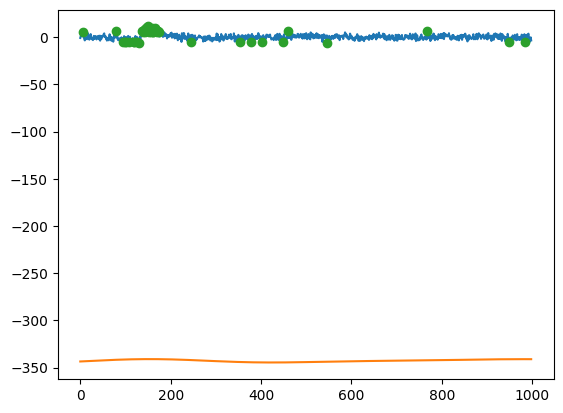

In [ ]:
from sklearn.ensemble import IsolationForest
new_data = data_sel - res
clf = IsolationForest(random_state=0, contamination=0.05).fit(new_data.reshape(-1, 1))
y_pred = clf.predict(new_data.reshape(-1, 1))
# y_res = list(y_pred).index(-1)
y_res = [i for i, x in enumerate(list(y_pred)) if x == -1]

plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), data_sel - res)
plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), res - 350)
plt.plot(np.array(range(len(data_sel))).reshape(-1, 1)[y_res], (data_sel - res)[y_res], "o")
mean2 = (380 - 310) / 2
ax = plt.gca()

plt.show()

Another peak finding function

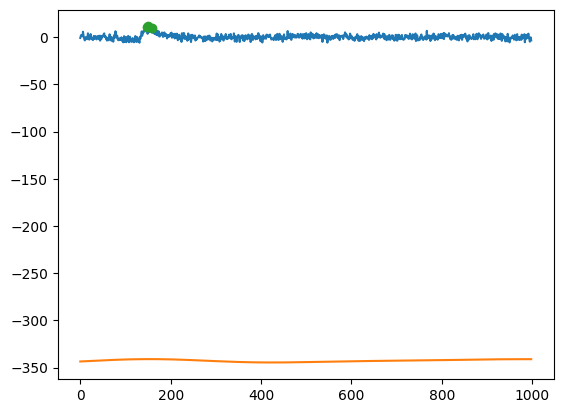

In [ ]:
from sklearn import linear_model
new_data = data_sel - res
clf = linear_model.SGDOneClassSVM(random_state=42, nu=0.131).fit(new_data.reshape(-1, 1))
y_pred = clf.predict(new_data.reshape(-1, 1))
# y_res = list(y_pred).index(-1)
y_res = [i for i, x in enumerate(list(y_pred)) if x == -1]

plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), data_sel - res)
plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), res - 350)
plt.plot(np.array(range(len(data_sel))).reshape(-1, 1)[y_res], (data_sel - res)[y_res], "o")
mean2 = (380 - 310) / 2
ax = plt.gca()

plt.show()

Another peak finding function

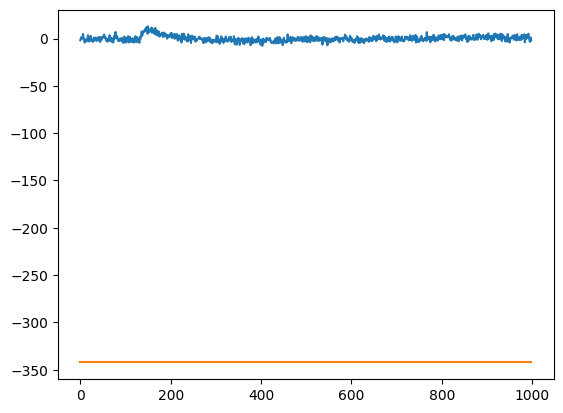

In [59]:
reg = Lasso().fit(np.array(range(len(data_sel))).reshape(-1, 1), data_sel)
res = reg.predict(np.array(range(len(data_sel))).reshape(-1, 1))

plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), data_sel - res)
plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), res - 350)
mean2 = (380 - 310) / 2
ax = plt.gca()

plt.show()

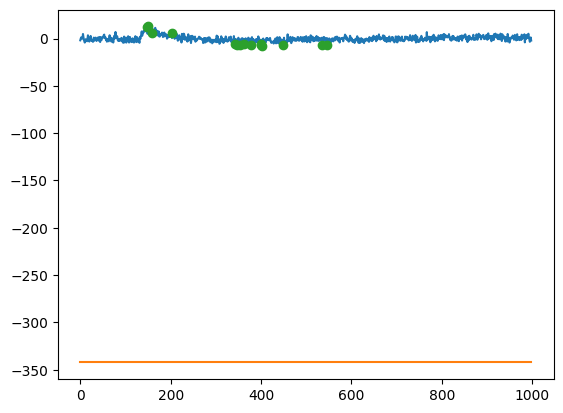

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
new_data = data_sel - res
clf = LocalOutlierFactor(n_neighbors=20)
y_pred = clf.fit_predict(new_data.reshape(-1, 1))
# y_res = list(y_pred).index(-1)
y_res = [i for i, x in enumerate(list(y_pred)) if x == -1]

plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), data_sel - res)
plt.plot(np.array(range(len(data_sel))).reshape(-1, 1), res - 350)
plt.plot(np.array(range(len(data_sel))).reshape(-1, 1)[y_res], (data_sel - res)[y_res], "o")
mean2 = (380 - 310) / 2
ax = plt.gca()

plt.show()

## Correlation analysis

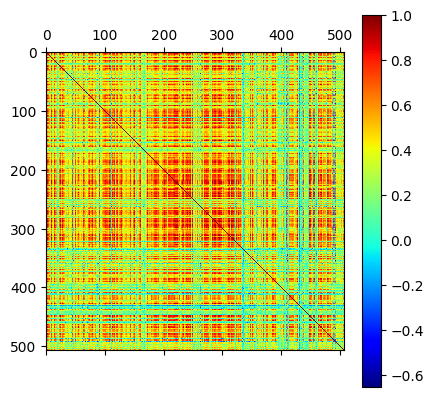

In [42]:
df = pd.DataFrame(norm_data)
corr1 = df.corr(method='pearson')
plt.matshow(corr1, cmap='jet')
plt.colorbar()
plt.show()

In [43]:
#df = pd.DataFrame(norm_data)
#corr = df.corr(method='kendall')
#plt.matshow(corr, cmap='jet')
#plt.colorbar()
#plt.show()

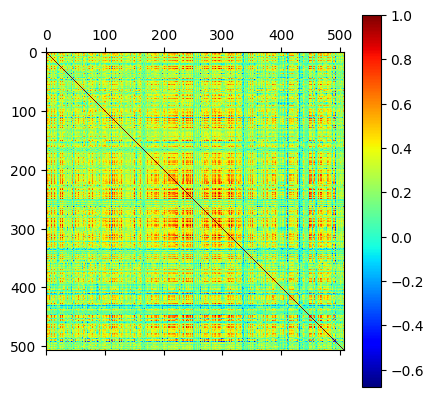

In [44]:
df = pd.DataFrame(norm_data)
corr = df.corr(method='spearman')
plt.matshow(corr, cmap='jet')
plt.colorbar()
plt.show()

In [45]:
def plot_corr(df,size=10):
    '''Plot a graphical correlation matrix for a dataframe.

    Input:
        df: pandas DataFrame
        size: vertical and horizontal size of the plot'''
    
    %matplotlib inline
    import matplotlib.pyplot as plt

    # Compute the correlation matrix for the received dataframe
    corr_func = df.corr()
    
    # Plot the correlation matrix
    fig, ax = plt.subplots(figsize=(size, size))
    # cax = ax.matshow(corr, cmap='RdYlGn')
    cax = ax.matshow(corr_func, cmap='jet')
    # plt.xticks(range(len(corr.columns)), corr.columns, rotation=90);
    # plt.yticks(range(len(corr.columns)), corr.columns);
    
    # Add the colorbar legend
    cbar = fig.colorbar(cax, ticks=[-1, 0, 1], aspect=40, shrink=.8)

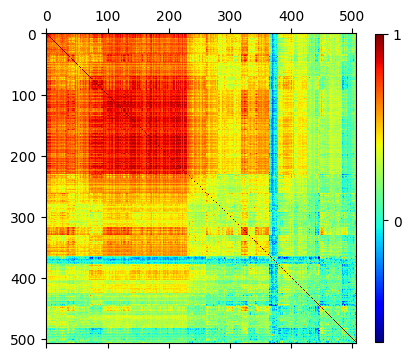

In [46]:
import scipy.cluster.hierarchy as sch
df = pd.DataFrame(norm_data)
X = corr1.values
d = sch.distance.pdist(X)   # vector of ('55' choose 2) pairwise distances
L = sch.linkage(d, method='complete')
# ind = sch.fcluster(L, 0.2*d.max(), 'distance')
ind = sch.fcluster(L, 50, criterion='maxclust')
columns = [df.columns.tolist()[i] for i in list((np.argsort(ind)))]
df = df.reindex(columns, axis=1)

plot_corr(df, size=5)

In [47]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs) # type: ignore

In [48]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None).fit(norm_data.transpose())
clustering.labels_.shape

(507,)

## Dendograms

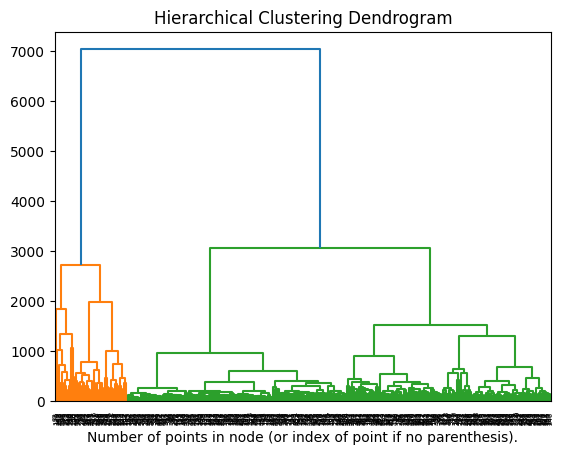

In [49]:
import math
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(clustering, truncate_mode="none", count_sort='none', show_contracted='true')
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

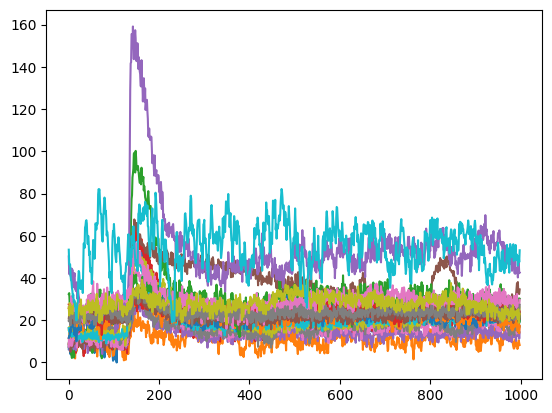

In [50]:
for i in range(20):
    plt.plot(np.array(range(len(norm_data[:, i]))).reshape(-1, 1), norm_data[:, i] + i)
ax = plt.gca()
plt.show()